<a href="https://colab.research.google.com/github/abhi102716/Rock-vs-Mine-Prediction/blob/main/Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Load Dataset

In [ ]:
df = pd.read_csv("/content/credit_data.csv")
print(df.head())
print(df.info())

   age  income  loan_amount  credit_history  existing_debt  employment_years  \
0   61   34592         2639               1          16049                 7   
1   27  108696        49540               0          38698                13   
2   22   32280        15328               0          33118                19   
3   56   46062        47925               1          14446                14   
4   38  126093         1425               0          27696                10   

   late_payments  target  
0              2       1  
1              0       1  
2              0       1  
3              9       0  
4              4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1000 non-null   int64
 1   income            1000 non-null   int64
 2   loan_amount       1000 non-null   int64
 3   credit_history    1000

Data Cleaning

In [ ]:
print(df.isnull().sum())
df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

age                 0
income              0
loan_amount         0
credit_history      0
existing_debt       0
employment_years    0
late_payments       0
target              0
dtype: int64


Feature engineering

In [ ]:
df["debt_income_ratio"] = df["existing_debt"] / df["income"]

In [ ]:
X = df.drop("target",axis=1)
Y = df["target"]
X_train_df, X_test_df, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train = X_train_df.values
X_test = X_test_df.values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800, 8)
X_test shape: (200, 8)


Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaler initialized and data scaled.")

Scaler initialized and data scaled.


In [ ]:
df["debt_income_ratio"] = df["existing_debt"] / df["income"]

In [ ]:
X = df.drop("target",axis=1)
Y = df["target"]
X_train_df, X_test_df, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train_df.values
X_test = X_test_df.values

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaler initialized and data scaled.")

Scaler initialized and data scaled.


Model Trainning

In [ ]:
#logistic regression
Ir_model = LogisticRegression()
Ir_model.fit(X_train, Y_train)
Ir_pred = Ir_model.predict(X_test)
#decision tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, Y_train)
dt_pred = dt_model.predict(X_test)
#random forest
rf_model = RandomForestClassifier(n_estimators = 100,random_state = 42)
rf_model.fit(X_train, Y_train)
rf_pred = rf_model.predict(X_test)

Matrix

In [ ]:
def evaluate_model(Y_test, predictions):

    print("Accuracy:",accuracy_score(Y_test, predictions))
    print("precision:",precision_score(Y_test, predictions))
    print("recall:",recall_score(Y_test, predictions))
    print("f1:",f1_score(Y_test, predictions))
    print("roc_auc:",roc_auc_score(Y_test, predictions))

print("Random Forest")
evaluate_model(Y_test, rf_pred)

Random Forest
Accuracy: 0.94
precision: 0.9238095238095239
recall: 0.9603960396039604
f1: 0.941747572815534
roc_auc: 0.9397939793979398


Confusion Matrix

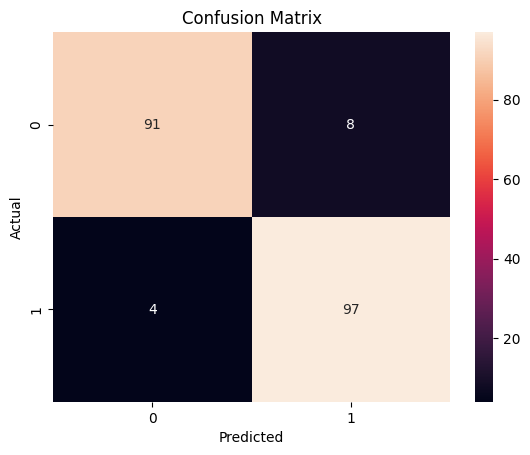

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Save Model

In [ ]:
import joblib
joblib.dump(rf_model, 'credit_score_model.pkl')

['credit_score_model.pkl']

Prediction Example

In [ ]:
sample_data = np.array([[
    35,
    50000,
    10000,
    1,
    5000,
    5,
    2,
    5000/50000
]])
sample_scaled = scaler.transform(sample_data)
prediction = rf_model.predict(sample_scaled)
if prediction[0] == 1:
    print("Credit Score: high")
else:
    print("Credit Score: low")

Credit Score: high
